# Forest Disturbance Detection with Multi-Kernel 1D U-Net
This notebook trains a 1D U-Net with multi-kernel convolutions to detect forest disturbance events in Landsat time series data.

## 1. Setup & Configuration

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from sklearn.model_selection import train_test_split
import random
pd.set_option('display.float_format', '{:.2f}'.format)
np.set_printoptions(suppress=True)
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

import os
print(os.getcwd())

/home/ubuntu/work/saved_data/landsat_disturbance_detection/clean_1D_U_Net/deep_disturbance/Multikernel_Model


In [2]:
import torch
import numpy as np
import random
import os

def set_seed(seed=1):
    """
    Set seeds for reproducibility.
    
    Args:
        seed (int): Seed value to use. Default is 42.
    """
    # Set Python seed
    random.seed(seed)
    
    # Set NumPy seed
    np.random.seed(seed)
    
    # Set PyTorch seed
    torch.manual_seed(seed)
    
    # Set CUDA seed if available
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # for multi-GPU
        
        # Additional CUDA settings for reproducibility
        torch.backends.cudnn.deterministic = True
        
    # Set environment variable for additional reproducibility
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    print(f"Random seed set to {seed}")

# Usage:
set_seed(42)  # or any other number you prefer

Random seed set to 42


## 2. Data Loading & Preprocessing

In [3]:
df = pd.read_csv('/home/ubuntu/work/saved_data/landsat_disturbance_detection/1D_U_Net/Data/Training/forest_dataset_timesync_alltiles_landsatbands_indices3_classes_ed5_calibration.csv',index_col=0, sep=';')
print(df.head())

# create disturbance labels
df['class'] = df['class_level1'].apply(lambda x: 1 if x == 'disturbance' else 0)
print(df.head(10))

import seaborn as sns
import matplotlib.pyplot as plt

# Plot distributions for each feature
features = ['GRN', 'RED', 'NIR', 'NBR', 'NDVI', 'TCB', 'TCG', 'TCW', 'SW1', 'SW2','DIn']

'''for feature in features:
    plt.figure(figsize=(3, 3))
    sns.kdeplot(df[df['new_class2_v5'] == 0][feature], label='Undisturbed', fill=True, color='blue')
    sns.kdeplot(df[df['new_class2_v5'] == 1][feature], label='Disturbed', fill=True, color='red')
    plt.title(f"{feature} Distribution by Class")
    plt.legend()
    plt.show()
'''


## filter doubtful samples
df = df[~((df['class_level1'] == 'treed') & (df['NBR'] < 0.5))]
df = df[~((df['class_level1'] == 'treed') & (df['NDVI'] < 0.5))]
df = df[~((df['class_level1'] == 'non-treed') & (df['NBR'] < 0.5))]
df = df[~((df['class_level1'] == 'non-treed') & (df['NDVI'] < 0.5))]
df = df[~((['class_level1'] == 'disturbance') & (df['NBR'] > 0.5))]
df = df[~((['class_level1'] == 'disturbance') & (df['NDVI'] > 0.5))]

# Count the number of samples per class
class_counts = df['class_level1'].value_counts()
print(class_counts)


     country  plotid  year class_level1 class_level2  new_class2_v5  uniqueid  \
fid                                                                             
0    albania       1  1985        treed        treed              0  albania1   
1    albania       1  1986        treed        treed              0  albania1   
2    albania       1  1987        treed        treed              0  albania1   
3    albania       1  1988        treed        treed              0  albania1   
4    albania       1  1989        treed        treed              0  albania1   

     numerical_id        x           y      Tile_ID     merged_id    BLU  \
fid                                                                        
0               1 20660.18 -1493987.48  X0036_Y0032  1985albania1   5.00   
1               1 20660.18 -1493987.48  X0036_Y0032  1986albania1 293.00   
2               1 20660.18 -1493987.48  X0036_Y0032  1987albania1 161.00   
3               1 20660.18 -1493987.48  X0036_Y0032 

In [4]:
import torch
from torch.optim import Adam
from torch.utils.tensorboard import SummaryWriter
from sklearn.model_selection import train_test_split

# Check CUDA availability
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Current Device:", torch.cuda.current_device())
    print("Device Name:", torch.cuda.get_device_name(torch.cuda.current_device()))
    torch.cuda.empty_cache()

CUDA Available: True
Current Device: 0
Device Name: NVIDIA GeForce RTX 3090


In [5]:


# Check CUDA availability
if not torch.cuda.is_available():
    print("CUDA is unavailable. Using CPU.")
    device = torch.device("cpu")
else:
    print("CUDA is available!")
    device = torch.device("cuda:0")
    torch.cuda.empty_cache()

# Test a small tensor on the GPU
try:
    x = torch.rand(3, 3).to(device)
    print("GPU Test Passed")
except RuntimeError as e:
    print(f"GPU Test Failed: {e}")

# Print GPU memory info
if torch.cuda.is_available():
    gpu_props = torch.cuda.get_device_properties(0)
    print(f"Total GPU Memory: {gpu_props.total_memory / (1024**3):.2f} GB")
    print(f"Allocated Memory: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
    print(f"Cached Memory: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")

CUDA is available!


GPU Test Passed
Total GPU Memory: 23.57 GB
Allocated Memory: 0.00 GB
Cached Memory: 0.00 GB


In [6]:
samples_data = []
samples_label = []

window_size = 8 # 16
missing = 0

for _, group in tqdm(df.groupby('uniqueid')):
    group = group.sort_values('year')
    if len(group) < 30:
        missing += 1
        continue
    #data = group[['NIR', 'SW1', 'SW2','NBR','NDVI','TCB','TCG','TCW','DIn']].diff().fillna(0)
    # Select the features you want to include (e.g., NBR, NDVI, TCW, SWIR) 
    #features = ['RED', 'SW1', 'SW2', 'NBR', 'NDVI', 'TCG', 'TCW', 'DIn']           #### TRY ADDING ALSO NIT AND TCB!!!
    features = ['BLU', 'GRN', 'RED', 'NIR', 'SW1', 'SW2'] 

    data = group[features]
    
    # Prepare the data using these features
    #data = group[['NBR']].fillna(0)
    
    #data = group[features].interpolate(method='linear', limit_direction='both') 
    '''data = (
    group
    .groupby('uniqueid')[features]
    .apply(lambda g: g.interpolate(method='linear', limit_direction='both'))
    .reset_index(drop=True)
)   '''
    label = group['new_class2_v5'].to_numpy()

    # Apply a rolling window of size to the data with slicing
    data = np.array([data[i:i+window_size].to_numpy() for i in range(len(data)-window_size+1)])
    label = np.array([label[i:i+window_size] for i in range(len(label)-window_size+1)])

    #data = data.reshape((1,data.shape[0],data.shape[1]))
    #label = label.reshape((1,len(label)))

    samples_data.append(data)
    samples_label.append(label)

X = samples_data
y = samples_label
print("missing")
print(missing)

import numpy as np
flat_labels = np.concatenate(samples_label).flatten()
print("Class balance:", np.bincount(flat_labels.astype(int)))

  0%|          | 0/16954 [00:00<?, ?it/s]

100%|██████████| 16954/16954 [00:13<00:00, 1254.41it/s]


missing
2551
Class balance: [2961016    8984]


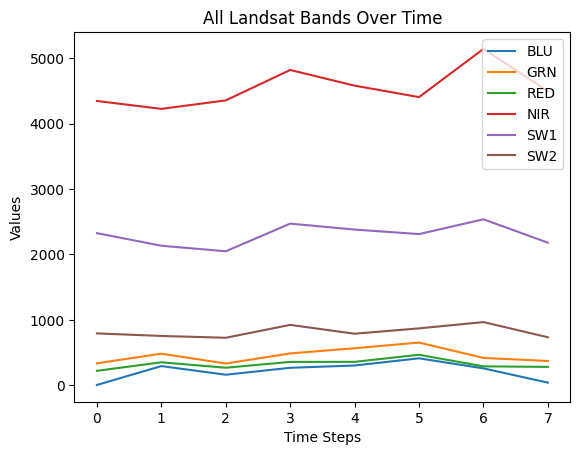

In [7]:
# plot the data for index 0
features = ['BLU', 'GRN', 'RED', 'NIR', 'SW1', 'SW2']

for i, feature_name in enumerate(features):
    plt.plot(X[0][0][:, i], label=feature_name)

plt.legend()
plt.xlabel('Time Steps')
plt.ylabel('Values')
plt.title('All Landsat Bands Over Time')
plt.show()



### Stratify and Train-Test Split

In [8]:
# Label each time window based on presence of any disturbance in the sequence
stratify_labels = [1 if np.any(np.array(label) == 1) else 0 for label in y]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0, stratify=stratify_labels)


'''these arrays have different shapes'''
# Flatten the first dimension
X_train_new = np.concatenate(X_train, axis=0)
X_test_new = np.concatenate(X_test, axis=0)
y_train_new = np.concatenate(y_train, axis=0)
y_test_new = np.concatenate(y_test, axis=0)

In [9]:
# Compute class weights
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1])
y_train_flat = y_train_new.flatten().astype(int)
weights = compute_class_weight('balanced', classes=classes, y=y_train_flat)
class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
print(f"Class weights: {class_weights}")

Class weights: tensor([  0.5015, 164.8449], device='cuda:0')


In [10]:
# Shuffle the data
def unison_shuffled_copies(a, b):
    assert len(a) == len(b)
    p = np.random.permutation(len(a))
    return a[p], b[p]

X_train_new, y_train_new = unison_shuffled_copies(X_train_new, y_train_new)
X_test_new, y_test_new = unison_shuffled_copies(X_test_new, y_test_new)

In [11]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import joblib

# Convert to numpy arrays
X_train = np.array(X_train_new, dtype=np.float32)
X_test = np.array(X_test_new, dtype=np.float32)

print(f"Before processing - X_train has NaN: {np.isnan(X_train).any()}")
print(f"Before processing - X_train NaN percentage: {np.isnan(X_train).mean() * 100:.1f}%")



'''scaler = MinMaxScaler()

X_train_2d = X_train.reshape(-1, X_train.shape[-1])
X_test_2d = X_test.reshape(-1, X_test.shape[-1])

# Fit scaler
scaler.fit(X_train_2d)

X_train_2d = scaler.transform(X_train_2d)
X_test_2d = scaler.transform(X_test_2d)

X_train_2d = X_train_2d.reshape(X_train.shape)
X_test_2d = X_test_2d.reshape(X_test.shape)'''




# STEP 1: Clean the data first
def clean_data_for_scaling(X):
    # Reshape to 2D
    X_2d = X.reshape(-1, X.shape[-1])
    
    # Replace NaN with a temporary sentinel value
    X_2d = np.nan_to_num(X_2d, nan=-9999, posinf=-9999, neginf=-9999)
    
    # Create mask for valid data (not the sentinel value)
    valid_mask = X_2d != -9999
    valid_rows = np.any(valid_mask, axis=1)
    
    print(f"Valid rows for scaling: {valid_rows.sum()} / {len(valid_rows)} ({valid_rows.mean()*100:.1f}%)")
    
    return X_2d, valid_rows

# Clean both datasets
X_train_2d, train_valid_rows = clean_data_for_scaling(X_train)
X_test_2d, test_valid_rows = clean_data_for_scaling(X_test)

# STEP 2: Fit scaler only on valid data
scaler = MinMaxScaler()

if train_valid_rows.sum() > 0:
    # Extract only valid training data for fitting
    valid_train_data = X_train_2d[train_valid_rows]
    print(f"Valid training data shape for scaler: {valid_train_data.shape}")
    print(f"Valid training data range: [{valid_train_data.min():.3f}, {valid_train_data.max():.3f}]")
    
    # Fit scaler
    scaler.fit(valid_train_data)
    
    # Transform valid data
    X_train_2d[train_valid_rows] = scaler.transform(X_train_2d[train_valid_rows])
    
    if test_valid_rows.sum() > 0:
        X_test_2d[test_valid_rows] = scaler.transform(X_test_2d[test_valid_rows])
else:
    print("ERROR: No valid training data found!")

# STEP 3: Set invalid data to 0 (matches inference)
X_train_2d[~train_valid_rows] = 0.0
X_test_2d[~test_valid_rows] = 0.0

# STEP 4: Final safety checks
X_train_2d = np.clip(X_train_2d, 0, 1)
X_test_2d = np.clip(X_test_2d, 0, 1)



# Save the scaler
joblib.dump(scaler, 'minmax_scaler.joblib')

# Reshape back to original shape
X_train_scaled = X_train_2d.reshape(X_train.shape)
X_test_scaled = X_test_2d.reshape(X_test.shape)

print(f"Scaling complete! Train range: [{X_train_scaled.min():.3f}, {X_train_scaled.max():.3f}]")
print(f"Test range: [{X_test_scaled.min():.3f}, {X_test_scaled.max():.3f}]")
print(f"Final data has NaN: {np.isnan(X_train_scaled).any()}")


Before processing - X_train has NaN: True
Before processing - X_train NaN percentage: 6.6%


Valid rows for scaling: 1858979 / 1990008 (93.4%)
Valid rows for scaling: 916101 / 979992 (93.5%)
Valid training data shape for scaler: (1858979, 6)
Valid training data range: [-416.000, 8228.000]
Scaling complete! Train range: [0.000, 1.000]
Test range: [0.000, 1.000]
Final data has NaN: False


In [12]:
# Prepare data for PyTorch
X_train_tensor = torch.Tensor(X_train_scaled).permute(0, 2, 1)  # (batch, time_steps, features)
X_test_tensor = torch.Tensor(X_test_scaled).permute(0, 2, 1)
y_train_tensor = torch.Tensor(y_train_new)
y_test_tensor = torch.Tensor(y_test_new)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# DataLoader for training and validation
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True, num_workers=1, persistent_workers=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=32, shuffle=False, num_workers=1, persistent_workers=True)

## 3. Model Definition

In [13]:
from multikernel_model import AlbasUNet
model = AlbasUNet().to(device)

In [14]:
# Train the U-Net model
from torch.optim import AdamW

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
optimizer = Adam(model.parameters())
# Training configuration
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr = 1e-4,
    weight_decay=0.01,  # L2 regularization
    betas=(0.9, 0.999),  # AdamW's betas
    eps=1e-8  # AdamW's eps
)

In [15]:
from sklearn.metrics import f1_score
from multikernel_model import FocalLoss

# Compute loss
# Count positives and negatives in training data
num_positives = y_train_tensor.sum()
num_negatives = len(y_train_tensor.view(-1)) - num_positives
        
# Compute pos_weight
pos_weight = num_negatives / (num_positives + 1e-6)  # Avoid div by zero
class_weights = torch.tensor([1.0, pos_weight], device=device)  # Not used directly, just for reference
# Define loss with pos_weight
'''loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)'''
#  or for focal loss:
'''Higher gamma penalizes easy examples more.
Slightly increasing alpha biases toward rare class (disturbance).'''
loss_fn = FocalLoss(alpha=2.0, gamma=2.0)  # You can tune alpha and gamma


In [16]:
def train_epoch_full_f1(model, train_loader, optimizer, device, loss_fn):
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        y_hat = model(x)
        loss = loss_fn(y_hat, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        probs = torch.sigmoid(y_hat)
        preds = (probs > 0.44).float()

        all_preds.append(preds.cpu())
        all_labels.append(y.cpu())

    all_preds = torch.cat(all_preds).view(-1).numpy()
    all_labels = torch.cat(all_labels).view(-1).numpy()

    train_f1 = f1_score(all_labels, all_preds, average = 'binary', zero_division=0)
    train_acc = accuracy_score(all_labels, all_preds)

    avg_loss = total_loss / len(train_loader)
    return avg_loss, train_acc,train_f1


In [17]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def evaluate_model(model, data_loader, device, criterion, threshold_range= [0.5] ): #[0.4, 0.42, 0.44, 0.46, 0.48, 0.5]):
    model.eval()
    all_probs = []
    all_labels = []
    total_loss = 0.0
    total_samples = 0

    with torch.no_grad():
        for batch_data, batch_labels in data_loader:
            batch_data = batch_data.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_data)
            if outputs.dim() == 3 and outputs.size(2) == 1:
                outputs = outputs.squeeze(2)

            loss = criterion(outputs, batch_labels)
            batch_size = batch_data.size(0)
            total_loss += loss.item() 
            #total_samples += batch_size

            probs = torch.sigmoid(outputs).cpu().numpy()
            labels = batch_labels.cpu().numpy()

            all_probs.extend(probs.reshape(-1).tolist())
            all_labels.extend(labels.reshape(-1).tolist())

    avg_loss = total_loss / len(data_loader)
    y_true = np.array(all_labels)
    all_probs = np.array(all_probs)

    best_f1 = -1
    best_thresh = threshold_range[0]
    best_acc = 0
    best_precision = 0
    best_recall = 0

    for thresh in threshold_range:
        y_pred = (all_probs > thresh).astype(int)

        f1 = f1_score(y_true, y_pred, zero_division=0)
        acc = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_thresh = thresh
            best_acc = acc
            best_precision = precision
            best_recall = recall

    print(f"[Validation] Best threshold: {best_thresh:.2f} | F1: {best_f1:.4f} | Acc: {best_acc:.4f} | Prec: {best_precision:.4f} | Rec: {best_recall:.4f}")

    return y_true, (all_probs > best_thresh).astype(int), avg_loss, best_acc, best_f1, best_precision, best_recall, best_thresh


## 4. Training Loop

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

best_val_f1 = 0.0
best_model_path = "best_model_2.pth"

train_losses = []
val_losses = []
train_accs = []
val_accs = []
train_f1s = []
val_f1s = []
val_precisions = []
val_recalls = []
val_thresholds = []

# LR scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=10, verbose=True, min_lr=1e-6)

# Training loop
for epoch in range(20):
    train_loss, train_acc, train_f1 = train_epoch_full_f1(model, train_loader, optimizer, device, loss_fn)  
    y_true_val, y_pred_val, val_loss, val_acc, val_f1, val_precision, val_recall, best_threshold = evaluate_model(model, val_loader, device, loss_fn, threshold_range=[0.4, 0.42, 0.44, 0.46, 0.48, 0.5])
    
    print(f'Epoch {epoch}, Train Loss: {train_loss:.4f}')
    print(f'Validation Loss: {val_loss:.4f}, Validation Acc: {val_acc:.4f}, Validation F1: {val_f1:.4f}, Best Threshold: {best_threshold:.4f}')

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    train_f1s.append(train_f1)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)
    val_precisions.append(val_precision)
    val_recalls.append(val_recall)
    val_thresholds.append(best_threshold)

    scheduler.step(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), best_model_path)
        print(f"New best validation F1: {best_val_f1:.4f}! Model saved.")

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[Validation] Best threshold: 0.40 | F1: 0.4615 | Acc: 0.9970 | Prec: 0.5024 | Rec: 0.4267
Epoch 0, Train Loss: 0.0095
Validation Loss: 0.0050, Validation Acc: 0.9970, Validation F1: 0.4615, Best Threshold: 0.4000
New best validation F1: 0.4615! Model saved.
[Validation] Best threshold: 0.42 | F1: 0.6088 | Acc: 0.9978 | Prec: 0.6443 | Rec: 0.5770
Epoch 1, Train Loss: 0.0062
Validation Loss: 0.0039, Validation Acc: 0.9978, Validation F1: 0.6088, Best Threshold: 0.4200
New best validation F1: 0.6088! Model saved.
[Validation] Best threshold: 0.44 | F1: 0.6914 | Acc: 0.9982 | Prec: 0.7231 | Rec: 0.6625
Epoch 2, Train Loss: 0.0055
Validation Loss: 0.0032, Validation Acc: 0.9982, Validation F1: 0.6914, Best Threshold: 0.4400
New best validation F1: 0.6914! Model saved.
[Validation] Best threshold: 0.44 | F1: 0.7068 | Acc: 0.9983 | Prec: 0.7556 | Rec: 0.6638
Epoch 3, Train Loss: 0.0053
Validation Loss: 0.0031, Validation Acc: 0.9983, Validation F1: 0.7068, Best Threshold: 0.4400
New best vali

## 5. Evaluation

ValueError: x and y must have same first dimension, but have shapes (20,) and (0,)

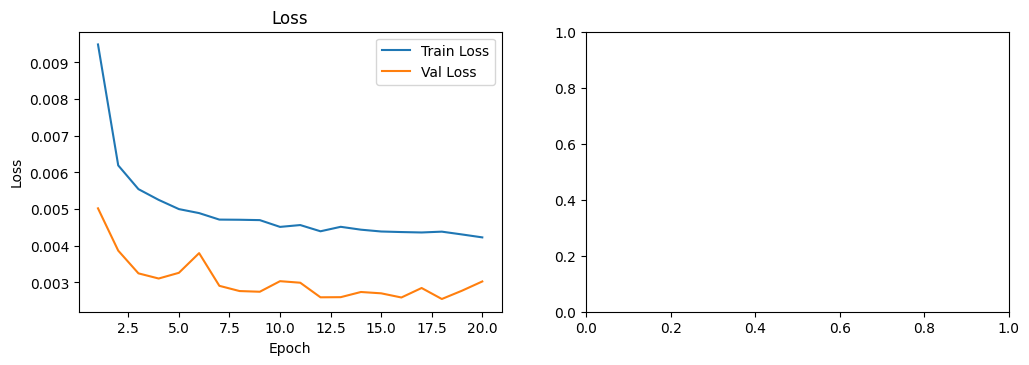

In [19]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(train_losses) + 1))

plt.figure(figsize=(12, 8))

# Loss
plt.subplot(2, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy
plt.subplot(2, 2, 2)
plt.plot(epochs, train_accs, label='Train Acc')
plt.plot(epochs, val_accs, label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# F1 Score
plt.subplot(2, 2, 3)
plt.plot(epochs, train_f1s, label='Train F1')
plt.plot(epochs, val_f1s, label='Val F1')
plt.title('F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1')
plt.legend()

# Precision, Recall, Threshold
plt.subplot(2, 2, 4)
plt.plot(epochs, val_precisions, label='Val Precision')
plt.plot(epochs, val_recalls, label='Val Recall')
plt.plot(epochs, val_thresholds, label='Best Threshold')
plt.title('Precision, Recall & Threshold')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()

plt.tight_layout()
plt.show()



Confusion Matrix:
[[975956   1088]
 [   725   2223]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    977044
         1.0       0.67      0.75      0.71      2948

    accuracy                           1.00    979992
   macro avg       0.84      0.88      0.85    979992
weighted avg       1.00      1.00      1.00    979992



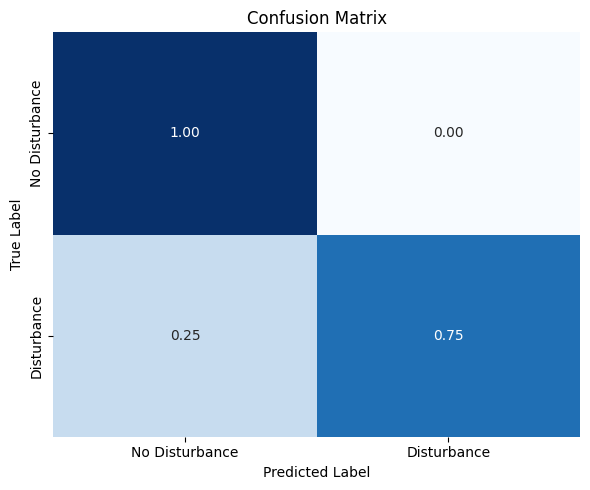

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

print("\nConfusion Matrix:")
print(confusion_matrix(y_true_val, y_pred_val))
print("\nClassification Report:")
print(classification_report(y_true_val, y_pred_val , zero_division=0))

def plot_confusion_matrix(y_true, y_pred, labels=["No Disturbance", "Disturbance"], normalize=True, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize else "d", cmap="Blues",
                xticklabels=labels, yticklabels=labels, cbar=False)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(y_true_val, y_pred_val)